In [69]:
import pandas as pd

In [70]:
yellow_data_jan = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
df = pd.read_parquet(yellow_data_jan)

# Q1. Downloading the data

We'll use the same NYC taxi dataset, but instead of "Green Taxi Trip Records", we'll use "Yellow Taxi Trip Records".

Download the data for January and February 2023.

Read the data for January. How many columns are there?

- 16
- 17
- 18
- 19 (correct)

In [71]:
print(f"There are {df.shape[1]} columns in 2023 January's data")

There are 19 columns in 2023 January's data


# Q2. Computing duration

Now let's compute the duration variable. It should contain the duration of a ride in minutes.

What's the standard deviation of the trips duration in January?
- 32.59
- 42.59 (correct)
- 52.59
- 62.59

In [72]:
duration_mins = (df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds() / 60
df['duration'] = duration_mins

print(f"The std dev of the trips in january is {df.duration.std():.2f}")

The std dev of the trips in january is 42.59


# Q3. Dropping outliers

Next, we need to check the distribution of the `duration` variable. There are some outliers. Let's remove them and keep only the records where the duration was between 1 and 60 minutes (inclusive).

What fraction of the records are left after you dropped the outliers?

* 90%
* 92%
* 95%
* 98% (correct)

In [73]:
total_rows = df.shape[0]
filtered_df = df[df.duration.between(1, 60)]
filtered_rows = filtered_df.shape[0]
fraction = filtered_rows * 100 / total_rows
df = filtered_df
print(f"Records left are a {int(fraction)}% fraction")


Records left are a 98% fraction


# Q4. One-hot encoding

Let's apply one-hot encoding to the pickup and dropoff location IDs. We'll use only these two features for our model. 

* Turn the dataframe into a list of dictionaries (remember to re-cast the ids to strings - otherwise it will 
  label encode them)
* Fit a dictionary vectorizer 
* Get a feature matrix from it

What's the dimensionality of this matrix (number of columns)?

* 2
* 155
* 345
* 515 (correct)
* 715

In [74]:
# categorical as strings
df[['PULocationID', 'DOLocationID']] = df[['PULocationID', 'DOLocationID']].astype(str)

In [75]:
from sklearn.feature_extraction import DictVectorizer

train_dicts = df.loc[:, ['PULocationID', 'DOLocationID']].to_dict(orient="records")

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
Y_train = df['duration'].values


In [76]:
print(f"The dimensionality of the train data is {X_train.shape[1]} columns")

The dimensionality of the train data is 515 columns


# Q5. Training a model

Now let's use the feature matrix from the previous step to train a model. 

* Train a plain linear regression model with default parameters, where duration is the response variable
* Calculate the RMSE of the model on the training data

What's the RMSE on train?

* 3.64 (closest - I got 0.52)
* 7.64
* 11.64
* 16.64

In [77]:
from sklearn.linear_model import LinearRegression
import numpy as np

## the linear regression y_pred returns negative values lower than -1 thus the rmse cannot be calculated
# lr = LinearRegression()
# lr.fit(X_train, Y_train)

# chatgpt solution is to predict ver the log and convert back to minutes
Y_train_log = np.log1p(Y_train)

model = LinearRegression()
model.fit(X_train, Y_train_log)


y_pred_log = model.predict(X_train)
y_pred = np.expm1(y_pred_log)


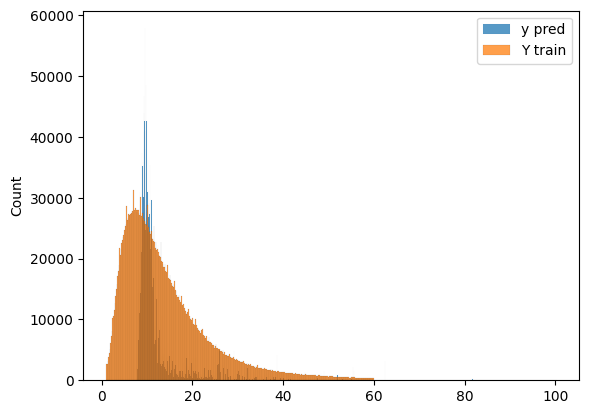

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.histplot(y_pred, label='y pred')
sns.histplot(Y_train, label='Y train')
plt.legend()


In [78]:
from sklearn.metrics import root_mean_squared_log_error

rmse = root_mean_squared_log_error(Y_train, y_pred)

print(f"The RMSE of the model (with log) is {rmse:.2f}")

The RMSE of the model (with log) is 0.52


# Q6. Evaluating the model

Now let's apply this model to the validation dataset (February 2023). 

What's the RMSE on validation?

* 3.81 (closest - I got 0.53)
* 7.81
* 11.81
* 16.81

In [79]:

yellow_data_feb = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet"
df = pd.read_parquet(yellow_data_feb)


In [80]:

# calculate trip duration
df['duration'] =  (df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds() / 60

# clip trip duration 
df = df[df.duration.between(1, 60)]

# ohe for model data
df[['PULocationID', 'DOLocationID']] = df[['PULocationID', 'DOLocationID']].astype(str)


In [81]:

val_dicts = df.loc[:, ['PULocationID', 'DOLocationID']].to_dict(orient="records")

X_val = dv.transform(val_dicts)
Y_val = df['duration'].values


In [83]:

# predict over february's data
y_pred_log = model.predict(X_val)
y_pred = np.expm1(y_pred_log)

# validate model with RMSE
rmse = root_mean_squared_log_error(Y_val, y_pred)

print(f"The RMSE of the model (with log) for validation data is {rmse:.2f}")

The RMSE of the model (with log) for validation data is 0.53
